# Hybrydowy klasyfikator w bibliotece QAILab

## Dane
Zacznijmy od załadowania naszego zbioru danych.  
Zbiór danych na którym będziemy pracować zawiera cyfry od 0 do 9, jednak aby zminimalizować liczbę kubitów (przyspieszy to trenowanie sieci) ograniczymy się do rozpoznawania tylko zer i jedynek.  
Pierwszym krokiem jaki musimy wykonać jest pobranie zbioru MNIST.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

# Obrazy dostajemy w formie DataFrame 
# (forma podobna do tabelek w programie excel)
images: pd.DataFrame = mnist['data']
labels: pd.Series = mnist['target']

# Zamieniamy formę DataFrame na szare obrazy 28x28 pikseli
images_np = images.values.reshape((-1,1, 28, 28))/255
labels_np = labels.values

Po pobraniu zbioru danych musimy go przefiltrować oraz sprowadzić do formy zrozumiałej dla sieci.  
Lista *labels* to lista prawdziwych klas dla każdego obrazu. Jako, że nasza sieć będzie zwracać listę prawdopodobieństw (np. 25% szansy, że obraz przedstawia zero i 75% szansy, że przedstawia jeden), chcemy zapisać prawdziwe klasy jako rozkłady prawdopodobieństwa.  
Pozwala nam na to kodowanie one-hot. Kodowanie one-hot generuje wektory o długości równej liczbie wszystkich klas, w których wartość na indeksie przypisanym do danej klasy to 1, a reszta wartości to 0.  
Perfekcyjnie nauczona sieć powinna zawsze przypisywać 100% pewności dla odpowiedniej klasy.

In [2]:
# Wybieramy indeksy w których obraz jest zerem lub jedynką
filter_indices = np.where((labels_np == '0') + (labels_np == '1'))

# Używamy jedynie obrazów o tych indeksach, reszta to inne cyfry
filtered_images = images_np[filter_indices]
filtered_labels = labels_np[filter_indices]

# Zamieniamy opisy obrazów z tekstu na reprezentację one-hot
string_to_one_hot = lambda s: np.array([1,0]) if s == '0' else np.array([0,1])
final_labels = np.array([string_to_one_hot(s) for s in filtered_labels],dtype=np.float32)

Na koniec podzielimy zbiór na dwie części: treningową i testową.  
Część testowa pozwoli nam ocenić jak nasza sieć radzi sobie na nowych, nigdy nie widzianych danych.

In [3]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(filtered_images,final_labels, test_size=0.15, shuffle=True)

Na grafice poniżej możemy zobaczyć kilka przykładów z naszego zbioru danych, wraz z prawdziwymi klasami zapisanymi w formacie one-hot:

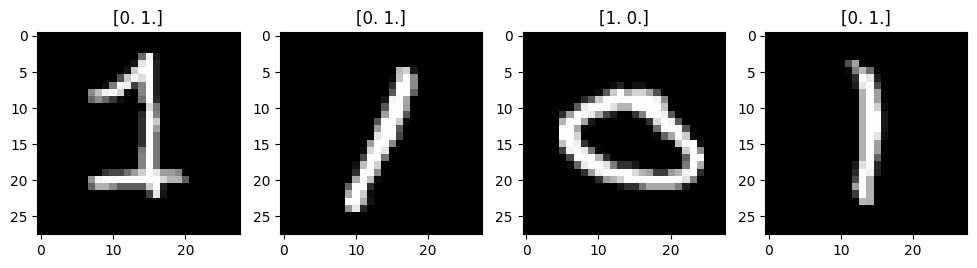

In [4]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1, 4, figsize=(12, 12))
axs = axs.flatten()
for i, ax in zip(range(4), axs):
       ax.imshow(train_X[i][0],cmap='gray')
       ax.set_title(f'{train_y[i]}')

plt.show()

## Sieć neuronowa
Do budowy warstwy kwantowej użyjemy biblioteki *QAILab*, kompatybilnej z PyTorch.  
Zacznijmy od stworzenia obwodu warstwy kwantowej.
Nasza warstwa będzie przyjmować 3 wartości wejściowe i zwracać 2 wartości wyjściowe.  
Jako enkoder wartości wejściowych użyjemy bramek $Rx$, natomiast wartości wag zostaną zakodowane obwodem *RealAmplitudes* (połączenie bramek $Ry$ oraz $Cx$)

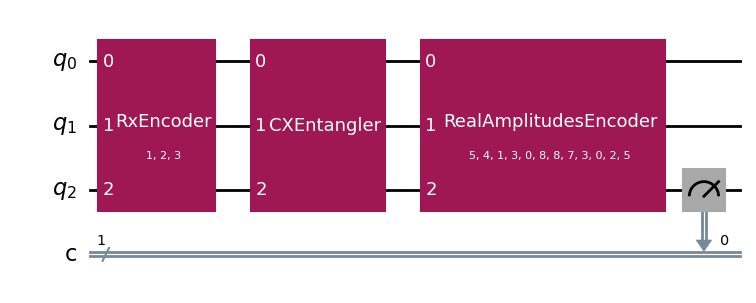

In [5]:
from qailab.circuit import build_circuit, RotationalEncoder, CXEntangler, RealAmplitudesBlock
from qailab.circuit.utils import assign_input_weight

qnn_circuit = build_circuit(
    3,
    [
        RotationalEncoder('x','input'), # Wartości wejścia
        CXEntangler(),
        RealAmplitudesBlock('weight'), # Wagi warstwy
    ],
    measure_qubits=[2]
    )


qnn_circuit.assign_parameters(assign_input_weight(qnn_circuit,[1,2,3],np.random.randint(0,9,12))).draw('mpl')

Po zdefiniowaniu obwodu dla warstwy kwantowej możemy przejść do zbudowania całej sieci hybrydowej.  
Będzie się ona składać z kilku warstw konwolucyjnych z funkcją aktywacji ReLU, dwóch warstw liniowych, oraz warstwy kwantowej, z obwodem utworzonym powyżej, na samym końcu.

In [6]:
import torch.nn as nn 

from qailab.torch import QLayer,QModel
from qlauncher.routines.qiskit import QiskitBackend

# Możliwość użycia kilku komputerów na raz w celu przyspieszenia treningu/inferencji
qlayer = QLayer(qnn_circuit, backends=[QiskitBackend('local_simulator'),QiskitBackend('local_simulator')]) 

sequential_net = nn.Sequential(
    nn.Conv2d(in_channels=1,out_channels=8,kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=8,out_channels=32,kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(800, 128),
    nn.ReLU(),
    nn.Linear(128, qlayer.in_features), #Klasa QLayer posiada 2 przydatne zmienne pomagające przy budowie sieci: in_features i out_features
    qlayer
    
)

# Klasa-wrapper kompatybilna z scikit-learn
model = QModel(
    module=sequential_net,
    loss=nn.CrossEntropyLoss(),
    optimizer_type='adam',
    learning_rate=0.001,
    batch_size=4,
    epochs=4,
    metric="accuracy"
    )

## Uczenie sieci
Utworzony model możemy wytrenować na małej części naszego zbioru danych (tyle danych wystarczy do osiągnięcia dobrego wyniku)

In [7]:
model.fit(train_X[:200],train_y[:200])
pass

100%|██████████| 4/4 [02:30<00:00, 37.54s/epochs, acc=1, epoch=4, loss=0.359]    


## Wyniki
Zobaczmy jak zmieniała się funkcja straty podczas treningu.

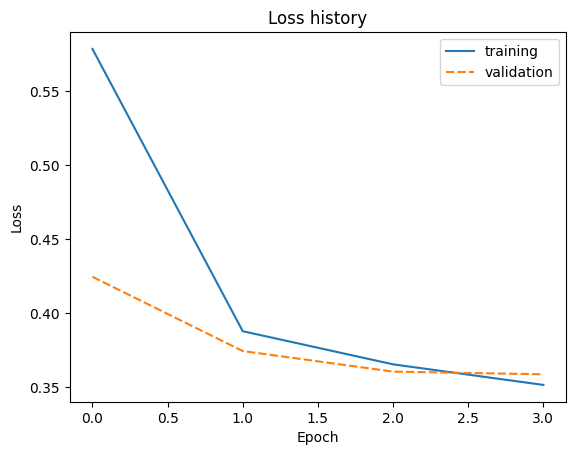

In [8]:
import seaborn as sns
sns.lineplot(model.loss_history)

plt.title('Loss history')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.show()

Sprawdźmy również jak model radzi sobie na danych testowych.

Test Accuracy:99.0%


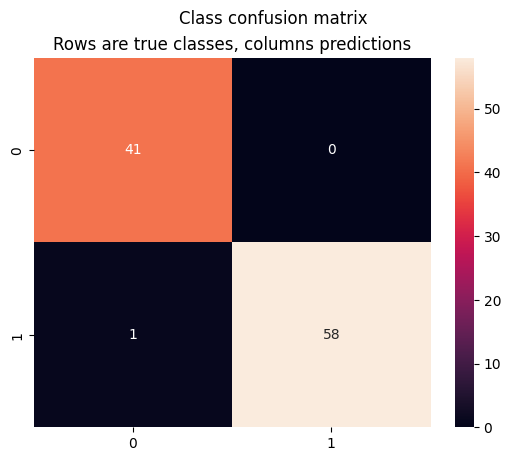

In [9]:
from sklearn.metrics import accuracy_score,confusion_matrix

truth,preds = np.argmax(test_y[:100],axis=1), model.predict(test_X[:100]).numpy().argmax(axis=1)
print(f"Test Accuracy:{accuracy_score(truth,preds) * 100}%")


conf_df = pd.DataFrame(confusion_matrix(truth,preds),index=[0,1],columns=[0,1])

sns.heatmap(conf_df,annot=True)
plt.suptitle("Class confusion matrix")
plt.title("Rows are true classes, columns predictions")
plt.show()